<a href="https://colab.research.google.com/github/gabrielcord/recpad20252/blob/main/Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Forecasting

**Aluno:** Gabriel Cordeiro

**Disciplina:** Redes Neurais Artificiais

**Semestre:** 2026/1

## Enunciado

Use as técnicas de forecasting apresentadas na aula em alguma base de dados diferente da apresentada na aula.

Lembre-se de usar uma técnica ingênua (Naïve) como baseline.

Explique a base que foi usada com poucas palavras. Justifique os parâmetros usados para gerar o dataset a partir do array.

## Solução

### Descrição da base

A base **Metro Interstate Traffic Volume** consiste em registros horários de volume de tráfego na rodovia I-94 (direção oeste) entre Minneapolis e St. Paul, abrangendo o período de 2012 a 2018. O conjunto de dados inclui variáveis de características meteorológicas e indicadores de feriados, visando a predição da demanda de tráfego por hora.

https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume

### Preparação do dataset

#### Download da base

In [24]:
!curl -L https://archive.ics.uci.edu/ml/machine-learning-databases/00492/Metro_Interstate_Traffic_Volume.csv.gz | gunzip > Metro_Interstate_Traffic_Volume.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  395k    0  395k    0     0   311k      0 --:--:--  0:00:01 --:--:--  311k


#### Carregamento e exploração dos dados

In [25]:
import pandas as pd

df = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')

In [26]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB
None


A análise inicial do dataset revelou 48.204 registros, expondo a necessidade de tratamento de dados antes da modelagem. Identificou-se que a coluna 'holiday' apresenta alta vacuidade, contendo apenas 61 valores não nulos, enquanto a coluna 'date_time' e outras variáveis categóricas estão classificadas como objetos, exigindo conversão para tipos temporais e codificação numérica para viabilizar o processamento por redes neurais.

In [27]:
print(df.head())

  holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0     NaN  288.28      0.0      0.0          40       Clouds   
1     NaN  289.36      0.0      0.0          75       Clouds   
2     NaN  289.58      0.0      0.0          90       Clouds   
3     NaN  290.13      0.0      0.0          90       Clouds   
4     NaN  291.14      0.0      0.0          75       Clouds   

  weather_description            date_time  traffic_volume  
0    scattered clouds  2012-10-02 09:00:00            5545  
1       broken clouds  2012-10-02 10:00:00            4516  
2     overcast clouds  2012-10-02 11:00:00            4767  
3     overcast clouds  2012-10-02 12:00:00            5026  
4       broken clouds  2012-10-02 13:00:00            4918  


A visualização dos dados brutos confirma a estrutura cronológica do dataset, essencial para modelos de *forecasting*, e evidencia a natureza heterogênea das variáveis, que misturam dados meteorológicos contínuos, categorias climáticas e o volume de tráfego alvo. Esta inspeção inicial permitiu compreender a relação entre as colunas e confirmar que a ordenação temporal das observações será o eixo condutor para a criação das janelas de tempo utilizadas no treinamento da rede neural.

In [28]:
print(df.nunique())

holiday                   11
temp                    5843
rain_1h                  372
snow_1h                   12
clouds_all                60
weather_main              11
weather_description       38
date_time              40575
traffic_volume          6704
dtype: int64


A contagem de valores únicos revelou discrepâncias significativas na coluna 'date_time', que possui menos registros que o total de linhas do dataset, indicando a presença de duplicatas. Além disso, a baixa cardinalidade das variáveis de clima e feriados confirmou que elas são adequadas para processos de codificação categórica, enquanto a alta variabilidade das colunas numéricas aponta para a necessidade de normalização antes do treinamento do modelo.

In [29]:
dups = df[df.duplicated(subset=['date_time'], keep=False)]
print(dups.sort_values(by='date_time').head(10))

    holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
178     NaN  281.25      0.0      0.0          99         Rain   
179     NaN  281.25      0.0      0.0          99      Drizzle   
180     NaN  280.10      0.0      0.0          99         Rain   
181     NaN  280.10      0.0      0.0          99      Drizzle   
182     NaN  279.61      0.0      0.0          99         Rain   
183     NaN  279.61      0.0      0.0          99      Drizzle   
269     NaN  282.43      0.0      0.0          57      Drizzle   
270     NaN  282.43      0.0      0.0          57         Mist   
271     NaN  282.43      0.0      0.0          57         Haze   
272     NaN  282.33      0.0      0.0          57      Drizzle   

         weather_description            date_time  traffic_volume  
178               light rain  2012-10-10 07:00:00            6793  
179  light intensity drizzle  2012-10-10 07:00:00            6793  
180               light rain  2012-10-10 08:00:00            6283  
1

A investigação das duplicatas confirmou a existência de múltiplos registros para o mesmo intervalo de tempo, com variações nas descrições meteorológicas. Esse conflito torna necessária a aplicação de um método de agregação para garantir a unicidade dos dados temporais, evitando que o modelo receba informações contraditórias para um mesmo ponto no tempo e mantendo a integridade da série temporal.

#### Tratamento das colunas

In [30]:
import pandas as pd

# Converter para datetime e tratar feriados
df['date_time'] = pd.to_datetime(df['date_time'])
df['is_holiday'] = df['holiday'].notna().astype(int)

# Criar as features temporais (Hora e Dia da Semana)
df['day_of_week'] = df['date_time'].dt.dayofweek
df['hour'] = df['date_time'].dt.hour

# Criar dummies para o clima e concatenar
weather_dummies = pd.get_dummies(df['weather_main'])
cols_to_keep = ['date_time', 'temp', 'rain_1h', 'snow_1h', 'clouds_all',
                'is_holiday', 'day_of_week', 'hour', 'traffic_volume']

df_full = pd.concat([df[cols_to_keep], weather_dummies], axis=1)

# Agrupar pela média para resolver as duplicatas e alinhar o tempo
df_final = df_full.set_index('date_time').groupby('date_time').mean()

# Transformar em array numpy
raw_data = df_final.values.astype('float32')

# Definir o target
target_idx = df_final.columns.get_loc('traffic_volume')
traffic = raw_data[:, target_idx]

print(f"Shape final do raw_data: {raw_data.shape}")
print(f"Shape do target: {traffic.shape}")

Shape final do raw_data: (40575, 19)
Shape do target: (40575,)


Nesta etapa, o dataset foi enriquecido com novas variáveis temporais (hora do dia e dia da semana) e binárias (indicação de feriado), conferindo ao modelo maior sensibilidade aos padrões cíclicos de tráfego. Para garantir a unicidade temporal, os registros duplicados foram tratados por meio de uma agregação pela média. Essa abordagem, ao ser aplicada às colunas codificadas por *One-Hot Encoding*, resulta em um *Soft Encoding*, que preserva a incerteza estatística presente nos conflitos do dataset original e evita a necessidade de exclusões arbitrárias, assegurando a continuidade e a integridade da série temporal para o treinamento da rede neural.

#### Divisão e normalização

In [31]:
# Definir os pontos de corte
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))

# Calcular estatísticas apenas com os dados de treino
train_data = raw_data[:num_train_samples]
mean = train_data.mean(axis=0)
std = train_data.std(axis=0)

# Normalizar todo o raw_data
raw_data -= mean
raw_data /= std

Para garantir um treinamento robusto e evitar vazamento de dados, a normalização foi calculada utilizando apenas os dados do conjunto de treinamento, mantendo a escala consistente em todo o dataset. Seguindo a natureza sequencial das séries temporais, a divisão dos dados entre treino, validação e teste respeitou estritamente a ordem cronológica, garantindo que a rede neural aprenda os padrões de tráfego sem o risco de contaminação por informações futuras.

#### Janelamento

In [32]:
import tensorflow as tf

# O sequence_length de 24h captura o ciclo diário completo
sequence_length = 24

# O delay (sequence_length + 0) garante que o alvo seja o próximo passo imediato (t+1).
delay = sequence_length + 0

# Processa cada registro horário do dataset sem saltos temporais
sampling_rate = 1

batch_size = 256

# Janelamento para treino
train_dataset = tf.keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=traffic[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples)

# Janelamento para validação
val_dataset = tf.keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=traffic[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples)

# Janelamento para teste
test_dataset = tf.keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=traffic[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples)

#### Escolha dos parâmetros

Foi definido um `sequence_length` de 24 para garantir que o modelo processe um ciclo diário completo, permitindo a identificação de padrões de comportamento intra-diários recorrentes.

O `delay` foi ajustado em 24 (equivalente ao `sequence_length`) para que a predição foque na próxima hora subsequente (t+1).

A `sampling_rate` foi mantida em 1, respeitando a granularidade horária original dos dados.

### Aplicação de modelos

#### Baseline (Naïve)

In [33]:
import numpy as np

def evaluate_naive_method(dataset, target_idx):
    total_abs_err = 0
    samples_seen = 0

    for samples, targets in dataset:
        preds = samples[:, -1, target_idx]

        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]

    return total_abs_err / samples_seen

Implementação da previsão ingênua para estabelecer um limite inferior de desempenho (o quão bem o modelo precisa ir para ser considerado útil). A previsão assume persistência: o valor de t+1 é igual ao último valor do histórico (t), após desnormalização.

In [34]:
val_mae_norm = evaluate_naive_method(val_dataset, target_idx)
val_mae_real = val_mae_norm * std[target_idx]

test_mae_norm = evaluate_naive_method(test_dataset, target_idx)
test_mae_real = test_mae_norm * std[target_idx]

print(f"Validation MAE: {val_mae_norm:.4f} (norm) | {val_mae_real:.2f} (real)")
print(f"Test MAE: {test_mae_norm:.4f} (norm) | {test_mae_real:.2f} (real)")

Validation MAE: 0.2890 (norm) | 581.52 (real)
Test MAE: 0.2941 (norm) | 591.78 (real)


#### Densely Connected

In [35]:
inputs = tf.keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = tf.keras.layers.Flatten()(inputs)
x = tf.keras.layers.Dense(16, activation='relu')(x)
outputs = tf.keras.layers.Dense(1)(x)

model = tf.keras.Model(inputs, outputs)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint('metro_dense.keras', save_best_only=True)
]

model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])

# Treinamento
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 0.7608 - mae: 0.6175 - val_loss: 100.5462 - val_mae: 0.7825
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.3298 - mae: 0.4049 - val_loss: 64.4193 - val_mae: 0.6153
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.2280 - mae: 0.3334 - val_loss: 44.3913 - val_mae: 0.5660
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.1750 - mae: 0.2926 - val_loss: 37.4062 - val_mae: 0.4901
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - loss: 0.1468 - mae: 0.2666 - val_loss: 30.8660 - val_mae: 0.4601
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.1280 - mae: 0.2490 - val_loss: 19.5788 - val_mae: 0.4055
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.1168 - mae: 0.2357 - val_loss: 20.6921 - val_mae: 0.4000
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.1076 - mae: 0.2262 - val_loss: 18.1478 - val_mae: 0.3738
Epoch 9/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - lo

In [36]:
# Avaliação
model = tf.keras.models.load_model('metro_dense.keras')
test_metrics = model.evaluate(test_dataset)

test_mae_norm = test_metrics[1]
test_mae_real = test_mae_norm * std[target_idx]

print(f"Test MAE: {test_mae_norm:.4f} (norm) | {test_mae_real:.2f} (real)")

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0826 - mae: 0.2141
Test MAE: 0.2141 (norm) | 430.85 (real)


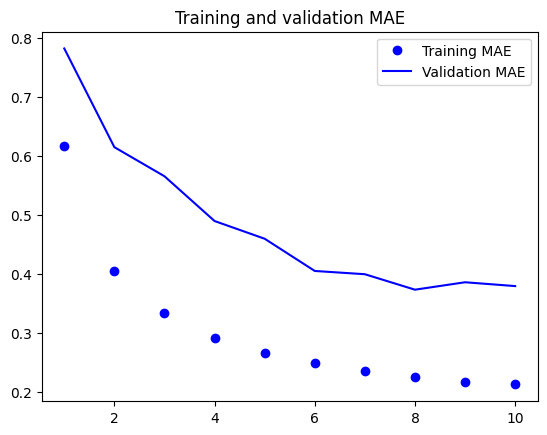

In [37]:
import matplotlib.pyplot as plt

loss = history.history['mae']
val_loss = history.history['val_mae']
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'bo', label='Training MAE')
plt.plot(epochs, val_loss, 'b', label='Validation MAE')
plt.title('Training and validation MAE')
plt.legend()
plt.show()

#### CNN 1D

In [38]:
inputs = tf.keras.Input(shape=(sequence_length, raw_data.shape[-1]))

x = tf.keras.layers.Conv1D(8, 24, padding='same', activation='relu')(inputs)
x = tf.keras.layers.MaxPooling1D(2)(x)
x = tf.keras.layers.Conv1D(8, 12, padding='same', activation='relu')(x)
x = tf.keras.layers.MaxPooling1D(2)(x)
x = tf.keras.layers.Conv1D(8, 6, padding='same', activation='relu')(x)

x = tf.keras.layers.GlobalAveragePooling1D()(x)
outputs = tf.keras.layers.Dense(1)(x)

model = tf.keras.Model(inputs, outputs)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint('metro_conv.keras', save_best_only=True)
]

model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])

# Treinamento
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - loss: 0.5503 - mae: 0.5877 - val_loss: 14.3076 - val_mae: 0.4952
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.2707 - mae: 0.3910 - val_loss: 11.4576 - val_mae: 0.4319
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.2086 - mae: 0.3353 - val_loss: 15.0068 - val_mae: 0.4173
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 0.1785 - mae: 0.3045 - val_loss: 9.0785 - val_mae: 0.3681
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.1623 - mae: 0.2866 - val_loss: 6.0635 - val_mae: 0.3082
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.1507 - mae: 0.2740 - val_loss: 4.5918 - val_mae: 0.2981
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 0.1407 - mae: 0.2627 - val_loss: 7.0491 - val_mae: 0.3474
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.1331 - mae: 0.2541 - val_loss: 11.1706 - val_mae: 0.3718
Epoch 9/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0

In [39]:
# Avaliação
model = tf.keras.models.load_model('metro_conv.keras')
test_metrics = model.evaluate(test_dataset)

test_mae_norm = test_metrics[1]
test_mae_real = test_mae_norm * std[target_idx]

print(f"Test MAE: {test_mae_norm:.4f} (norm) | {test_mae_real:.2f} (real)")

40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0784 - mae: 0.2092
Test MAE: 0.2092 (norm) | 420.92 (real)


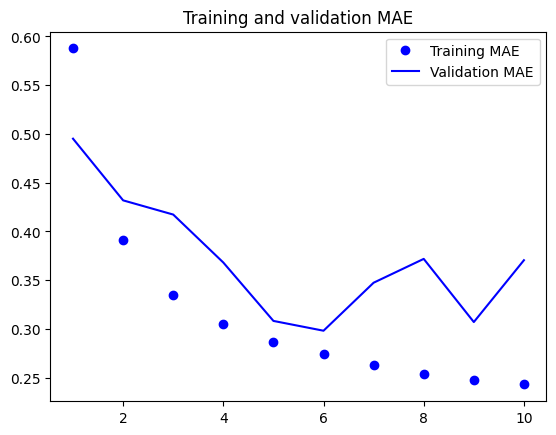

In [40]:
loss = history.history['mae']
val_loss = history.history['val_mae']
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'bo', label='Training MAE')
plt.plot(epochs, val_loss, 'b', label='Validation MAE')
plt.title('Training and validation MAE')
plt.legend()
plt.show()

#### LSTM

In [41]:
inputs = tf.keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = tf.keras.layers.LSTM(32)(inputs)
outputs = tf.keras.layers.Dense(1)(x)
model = tf.keras.Model(inputs=inputs, outputs=outputs)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("metro_lstm.keras", save_best_only=True)
]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

# Treinamento
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.5200 - mae: 0.5716 - val_loss: 0.2283 - val_mae: 0.3683
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.2288 - mae: 0.3542 - val_loss: 0.1534 - val_mae: 0.2991
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 0.1704 - mae: 0.2982 - val_loss: 0.1118 - val_mae: 0.2576
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.1351 - mae: 0.2588 - val_loss: 0.0784 - val_mae: 0.2098
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.1134 - mae: 0.2302 - val_loss: 0.0695 - val_mae: 0.2023
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.1027 - mae: 0.2140 - val_loss: 0.0593 - val_mae: 0.1797
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.0974 - mae: 0.2063 - val_loss: 0.0676 - val_mae: 0.2018
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.0943 - mae: 0.2014 - val_loss: 0.0513 - val_mae: 0.1651
Epoch 9/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: 0.091

In [42]:
# Avaliação
model = tf.keras.models.load_model("metro_lstm.keras")
test_metrics = model.evaluate(test_dataset)

test_mae_norm = test_metrics[1]
test_mae_real = test_mae_norm * std[target_idx]

print(f"Test MAE: {test_mae_norm:.4f} (norm) | {test_mae_real:.2f} (real)")

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0473 - mae: 0.1580
Test MAE: 0.1580 (norm) | 318.00 (real)


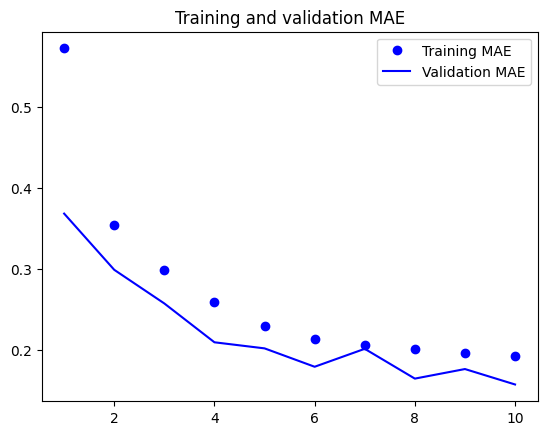

In [43]:
loss = history.history['mae']
val_loss = history.history['val_mae']
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'bo', label='Training MAE')
plt.plot(epochs, val_loss, 'b', label='Validation MAE')
plt.title('Training and validation MAE')
plt.legend()
plt.show()

#### Bidirectional LSTM

In [44]:
inputs = tf.keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32))(inputs)
outputs = tf.keras.layers.Dense(1)(x)
model = tf.keras.Model(inputs=inputs, outputs=outputs)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("metro_bidirectional_lstm.keras", save_best_only=True)
]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

# Treinamento
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 0.4780 - mae: 0.5428 - val_loss: 0.2084 - val_mae: 0.3532
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.2268 - mae: 0.3602 - val_loss: 0.1486 - val_mae: 0.3030
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.1634 - mae: 0.2965 - val_loss: 0.1044 - val_mae: 0.2484
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - loss: 0.1270 - mae: 0.2522 - val_loss: 0.0736 - val_mae: 0.2062
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 0.1071 - mae: 0.2231 - val_loss: 0.0593 - val_mae: 0.1776
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0974 - mae: 0.2078 - val_loss: 0.0561 - val_mae: 0.1742
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 0.0915 - mae: 0.1990 - val_loss: 0.0467 - val_mae: 0.1577
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.0880 - mae: 0.1930 - val_loss: 0.0638 - val_mae: 0.1920
Epoch 9/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.084

In [45]:
# Avaliação
model = tf.keras.models.load_model("metro_bidirectional_lstm.keras")
test_metrics = model.evaluate(test_dataset)

test_mae_norm = test_metrics[1]
test_mae_real = test_mae_norm * std[target_idx]

print(f"Test MAE: {test_mae_norm:.4f} (norm) | {test_mae_real:.2f} (real)")

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0394 - mae: 0.1497
Test MAE: 0.1497 (norm) | 301.22 (real)


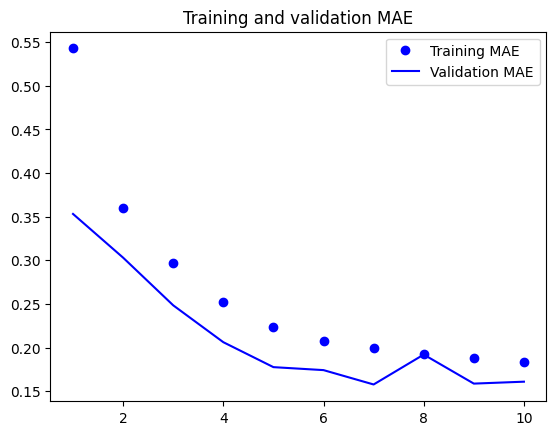

In [46]:
loss = history.history['mae']
val_loss = history.history['val_mae']
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'bo', label='Training MAE')
plt.plot(epochs, val_loss, 'b', label='Validation MAE')
plt.title('Training and validation MAE')
plt.legend()
plt.show()